In [1]:
# Week 5: Comprehensive Data Science Project
# Student Performance Analysis and Prediction

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Week 5 Project Initialized Successfully!")

Week 5 Project Initialized Successfully!


In [2]:
# Load the student performance dataset

df = pd.read_csv("StudentsPerformance.csv")

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

display(df.head())

print("\nDataset columns:")
print(df.columns.tolist())

Dataset loaded successfully!
Dataset shape: (1000, 8)


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75



Dataset columns:
['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course', 'math score', 'reading score', 'writing score']


In [3]:
# Basic dataset analysis

print("Dataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nDescriptive Statistics:")
display(df.describe())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB

Missing Values:
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writi

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [4]:
# Week 5 - Step 3: Overall Performance Analysis

# Calculate the average score for each student
df["average_score"] = (
    df["math score"] +
    df["reading score"] +
    df["writing score"]
) / 3

# Display overall score statistics
print("OVERALL STUDENT PERFORMANCE")
print("-" * 40)

print("Total Students:", len(df))
print("Average Math Score:", round(df["math score"].mean(), 2))
print("Average Reading Score:", round(df["reading score"].mean(), 2))
print("Average Writing Score:", round(df["writing score"].mean(), 2))
print("Overall Average Score:", round(df["average_score"].mean(), 2))

print("\nHighest Average Score:", round(df["average_score"].max(), 2))
print("Lowest Average Score:", round(df["average_score"].min(), 2))

display(df[[
    "math score",
    "reading score",
    "writing score",
    "average_score"
]].head(10))

OVERALL STUDENT PERFORMANCE
----------------------------------------
Total Students: 1000
Average Math Score: 66.09
Average Reading Score: 69.17
Average Writing Score: 68.05
Overall Average Score: 67.77

Highest Average Score: 100.0
Lowest Average Score: 9.0


,math score,reading score,writing score,average_score
0,72,72,74,72.666667
1,69,90,88,82.333333
2,90,95,93,92.666667
3,47,57,44,49.333333
4,76,78,75,76.333333
5,71,83,78,77.333333
6,88,95,92,91.666667
7,40,43,39,40.666667
8,64,64,67,65.000000
9,38,60,50,49.333333


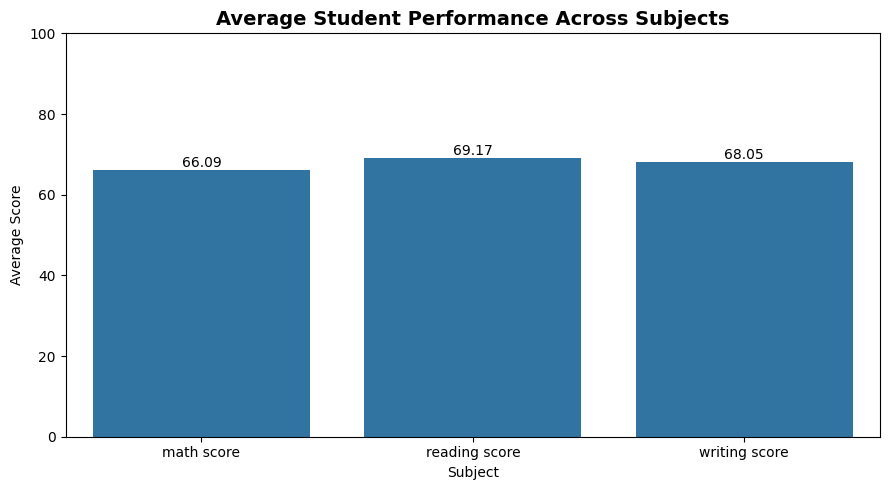

In [5]:
# Week 5 - Step 4: Subject Performance Comparison

import matplotlib.pyplot as plt
import seaborn as sns

subject_means = df[
    ["math score", "reading score", "writing score"]
].mean()

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    x=subject_means.index,
    y=subject_means.values
)

plt.title("Average Student Performance Across Subjects",
          fontsize=14, fontweight="bold")
plt.xlabel("Subject")
plt.ylabel("Average Score")
plt.ylim(0, 100)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.tight_layout()
plt.show()

Student Performance Category Counts:
performance_category
Medium    402
High      313
Low       285
Name: count, dtype: int64

Percentage Distribution:
performance_category
Medium    40.2
High      31.3
Low       28.5
Name: count, dtype: float64


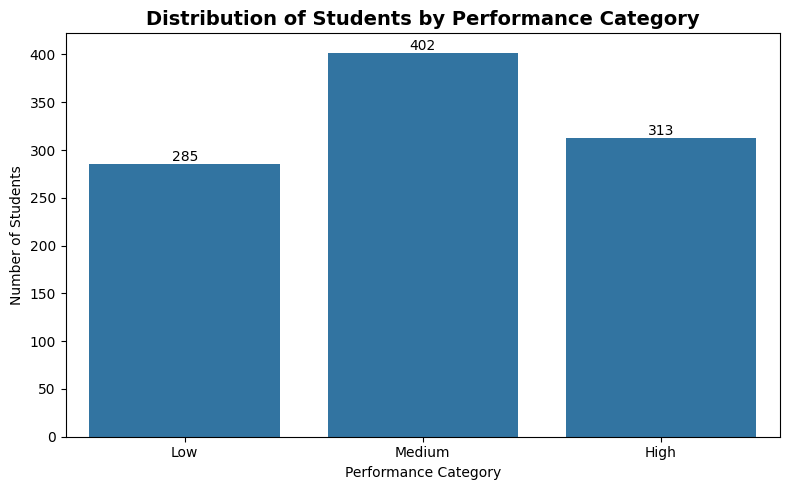

In [6]:
# Week 5 - Step 5: Student Performance Category Analysis

def categorize_performance(score):
    if score < 60:
        return "Low"
    elif score <= 75:
        return "Medium"
    else:
        return "High"

df["performance_category"] = df["average_score"].apply(
    categorize_performance
)

# Count students in each category
category_counts = df["performance_category"].value_counts()

print("Student Performance Category Counts:")
print(category_counts)

print("\nPercentage Distribution:")
print((category_counts / len(df) * 100).round(2))

# Visualize the distribution
plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df,
    x="performance_category",
    order=["Low", "Medium", "High"]
)

plt.title("Distribution of Students by Performance Category",
          fontsize=14, fontweight="bold")
plt.xlabel("Performance Category")
plt.ylabel("Number of Students")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

TEST PREPARATION COURSE ANALYSIS
---------------------------------------------


,count,mean,std
test preparation course,,,
completed,358,72.67,13.04
none,642,65.04,14.19


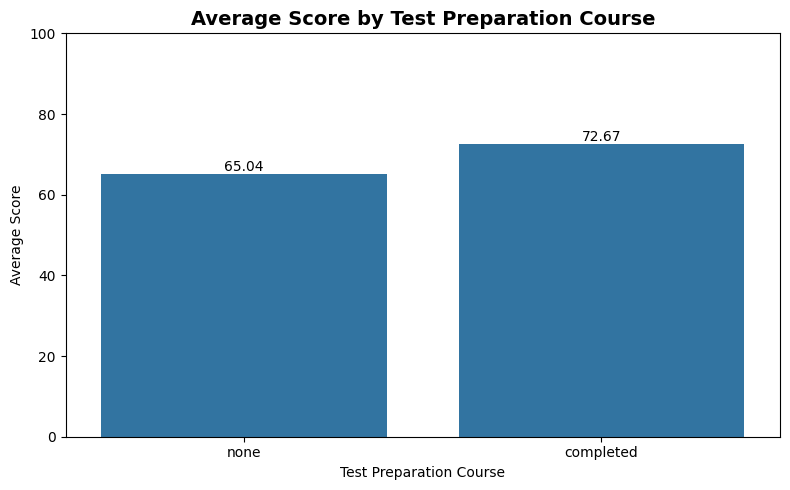

In [7]:
# Week 5 - Step 6: Test Preparation Analysis

# Calculate average scores by test preparation status
prep_analysis = df.groupby(
    "test preparation course"
)["average_score"].agg(
    ["count", "mean", "std"]
).round(2)

print("TEST PREPARATION COURSE ANALYSIS")
print("-" * 45)
display(prep_analysis)

# Visualize average scores
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=df,
    x="test preparation course",
    y="average_score",
    errorbar=None
)

plt.title("Average Score by Test Preparation Course",
          fontsize=14, fontweight="bold")
plt.xlabel("Test Preparation Course")
plt.ylabel("Average Score")
plt.ylim(0, 100)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.tight_layout()
plt.show()

PERFORMANCE BY PARENTAL EDUCATION
---------------------------------------------


,count,mean,std
parental level of education,,,
master's degree,59,73.60,13.60
bachelor's degree,118,71.92,13.95
associate's degree,222,69.57,13.67
some college,226,68.48,13.71
some high school,179,65.11,14.98
high school,196,63.10,13.51


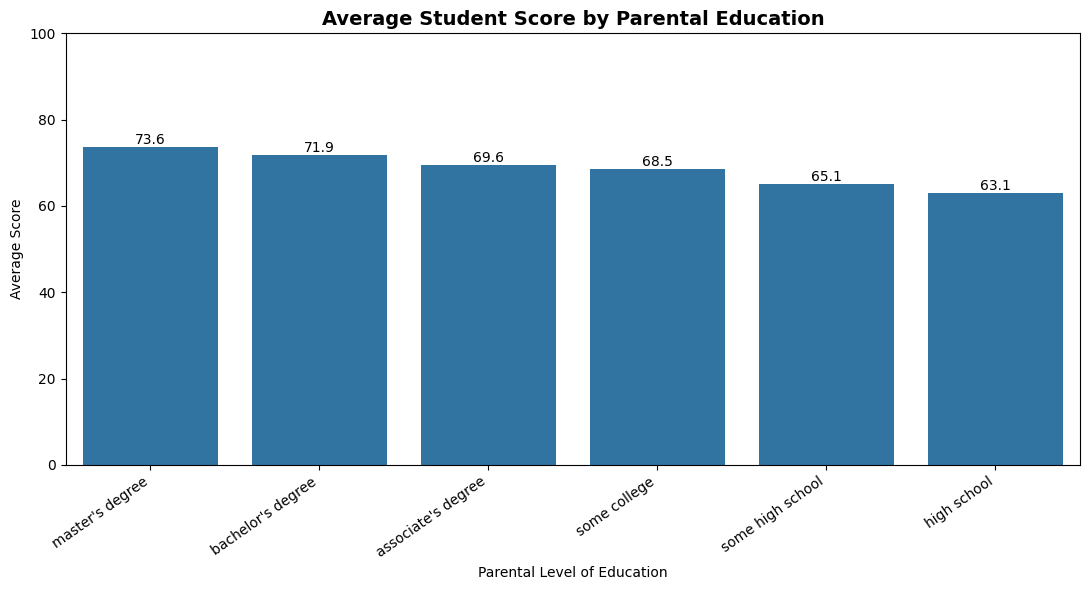

In [8]:
# Week 5 - Step 7: Parental Education Analysis

parent_analysis = df.groupby(
    "parental level of education"
)["average_score"].agg(
    ["count", "mean", "std"]
).round(2)

# Sort by average score
parent_analysis = parent_analysis.sort_values(
    by="mean", ascending=False
)

print("PERFORMANCE BY PARENTAL EDUCATION")
print("-" * 45)
display(parent_analysis)

# Visualization
plt.figure(figsize=(11, 6))

ax = sns.barplot(
    data=df,
    x="parental level of education",
    y="average_score",
    order=parent_analysis.index,
    errorbar=None
)

plt.title("Average Student Score by Parental Education",
          fontsize=14, fontweight="bold")
plt.xlabel("Parental Level of Education")
plt.ylabel("Average Score")
plt.xticks(rotation=35, ha="right")
plt.ylim(0, 100)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f")

plt.tight_layout()
plt.show()

STUDENT PERFORMANCE BY LUNCH TYPE
----------------------------------------


,count,mean,std
lunch,,,
free/reduced,355,62.20,14.46
standard,645,70.84,13.19


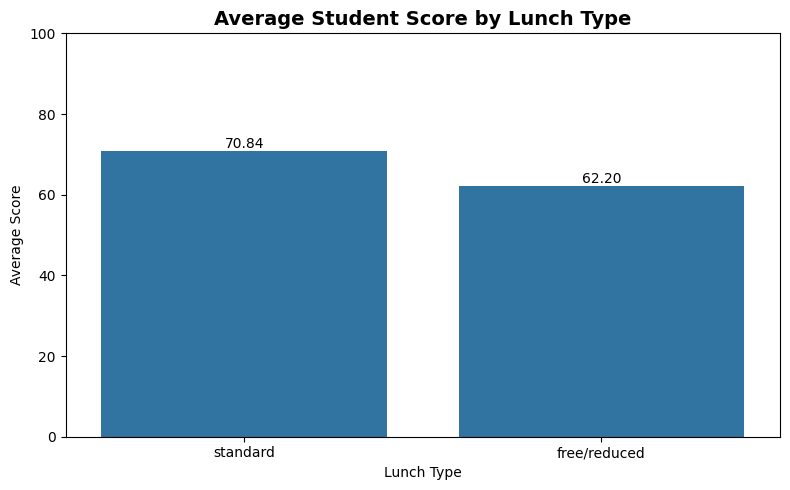

In [9]:

# Week 5 - Step 8: Lunch Type Analysis

lunch_analysis = df.groupby("lunch")["average_score"].agg(
    ["count", "mean", "std"]
).round(2)

print("STUDENT PERFORMANCE BY LUNCH TYPE")
print("-" * 40)
display(lunch_analysis)

# Visualize average scores
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=df,
    x="lunch",
    y="average_score",
    errorbar=None
)

plt.title("Average Student Score by Lunch Type",
          fontsize=14, fontweight="bold")
plt.xlabel("Lunch Type")
plt.ylabel("Average Score")
plt.ylim(0, 100)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.tight_layout()
plt.show()

GENDER-WISE SUBJECT PERFORMANCE
---------------------------------------------


,math score,reading score,writing score
gender,,,
female,63.63,72.61,72.47
male,68.73,65.47,63.31


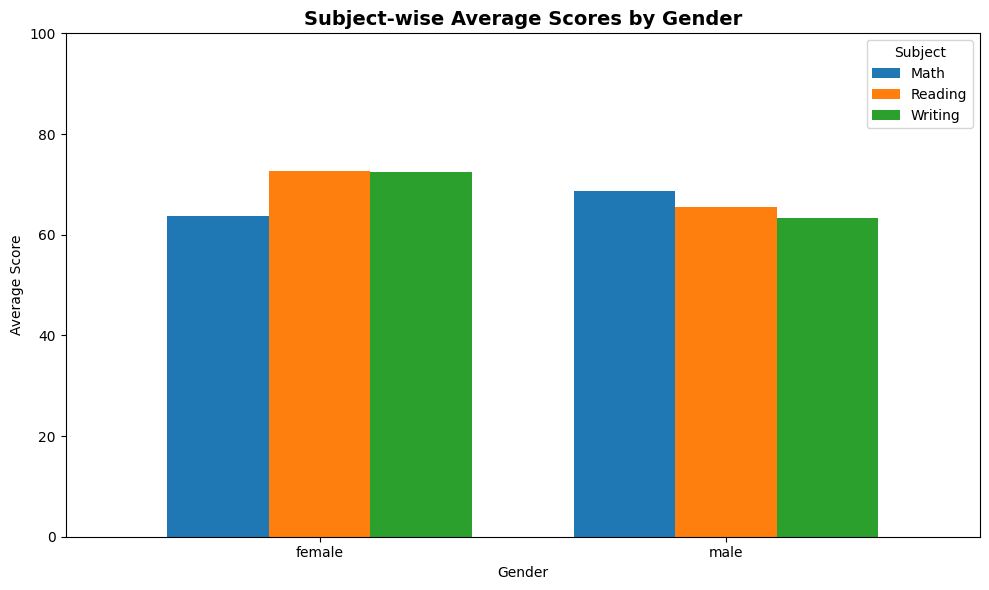

In [10]:

# Week 5 - Step 9: Gender and Subject-wise Analysis

subjects = ["math score", "reading score", "writing score"]

gender_analysis = df.groupby("gender")[subjects].mean().round(2)

print("GENDER-WISE SUBJECT PERFORMANCE")
print("-" * 45)
display(gender_analysis)

# Create comparison chart
gender_plot = df.groupby("gender")[subjects].mean()

ax = gender_plot.plot(
    kind="bar",
    figsize=(10, 6),
    width=0.75
)

ax.set_title(
    "Subject-wise Average Scores by Gender",
    fontsize=14,
    fontweight="bold"
)
ax.set_xlabel("Gender")
ax.set_ylabel("Average Score")
ax.set_ylim(0, 100)
ax.legend(
    ["Math", "Reading", "Writing"],
    title="Subject"
)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [11]:

# Week 5 - Step 10: Final Project Summary

print("=" * 60)
print("STUDENT PERFORMANCE ANALYSIS - FINAL PROJECT SUMMARY")
print("=" * 60)

print(f"\nTotal Students Analysed: {len(df)}")

print("\n1. SUBJECT-WISE AVERAGE SCORES")
for subject in ["math score", "reading score", "writing score"]:
    print(f"{subject.title()}: {df[subject].mean():.2f}")

print("\n2. OVERALL PERFORMANCE")
print(f"Overall Average: {df['average_score'].mean():.2f}")
print(f"Highest Average: {df['average_score'].max():.2f}")
print(f"Lowest Average: {df['average_score'].min():.2f}")

print("\n3. PERFORMANCE CATEGORY DISTRIBUTION")
print(df["performance_category"].value_counts())
print("\nPercentages:")
print((df["performance_category"].value_counts(normalize=True) * 100).round(2))

print("\n4. TEST PREPARATION COMPARISON")
prep_means = df.groupby("test preparation course")["average_score"].mean()
print(prep_means.round(2))
print(f"Mean Difference: {prep_means['completed'] - prep_means['none']:.2f} points")

print("\n5. LUNCH TYPE COMPARISON")
print(df.groupby("lunch")["average_score"].mean().round(2))

print("\n6. PARENTAL EDUCATION COMPARISON")
print(df.groupby("parental level of education")["average_score"].mean().sort_values(ascending=False).round(2))

print("\n7. DATA QUALITY")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Duplicate rows: {df.duplicated().sum()}")

print("\n" + "=" * 60)
print("FINAL PROJECT SUMMARY GENERATED SUCCESSFULLY!")
print("=" * 60)

STUDENT PERFORMANCE ANALYSIS - FINAL PROJECT SUMMARY

Total Students Analysed: 1000

1. SUBJECT-WISE AVERAGE SCORES
Math Score: 66.09
Reading Score: 69.17
Writing Score: 68.05

2. OVERALL PERFORMANCE
Overall Average: 67.77
Highest Average: 100.00
Lowest Average: 9.00

3. PERFORMANCE CATEGORY DISTRIBUTION
performance_category
Medium    402
High      313
Low       285
Name: count, dtype: int64

Percentages:
performance_category
Medium    40.2
High      31.3
Low       28.5
Name: proportion, dtype: float64

4. TEST PREPARATION COMPARISON
test preparation course
completed    72.67
none         65.04
Name: average_score, dtype: float64
Mean Difference: 7.63 points

5. LUNCH TYPE COMPARISON
lunch
free/reduced    62.20
standard        70.84
Name: average_score, dtype: float64

6. PARENTAL EDUCATION COMPARISON
parental level of education
master's degree       73.60
bachelor's degree     71.92
associate's degree    69.57
some college          68.48
some high school      65.11
high school        

In [12]:

# Week 5 - Step 11: Statistical Evidence Summary

import numpy as np
from scipy import stats

# 1. Independent Samples T-Test
completed = df.loc[
    df["test preparation course"] == "completed", "average_score"
]
not_completed = df.loc[
    df["test preparation course"] == "none", "average_score"
]

t_stat, t_p = stats.ttest_ind(completed, not_completed, equal_var=True)

# 2. Chi-Square Test: Lunch Type vs Performance Category
contingency = pd.crosstab(df["lunch"], df["performance_category"])
chi_stat, chi_p, chi_df, expected = stats.chi2_contingency(contingency)

# 3. One-Way ANOVA: Parental Education Groups
education_groups = [
    group["average_score"].values
    for _, group in df.groupby("parental level of education")
]
f_stat, anova_p = stats.f_oneway(*education_groups)

# 4. 95% Confidence Interval for Overall Average Score
scores = df["average_score"].dropna()
mean_score = scores.mean()
sem_score = stats.sem(scores)
ci_low, ci_high = stats.t.interval(
    0.95, df=len(scores) - 1, loc=mean_score, scale=sem_score
)

print("=" * 60)
print("STATISTICAL EVIDENCE FOR THE FINAL REPORT")
print("=" * 60)

print("\n1. Test Preparation - Independent Samples T-Test")
print(f"Completed group mean: {completed.mean():.2f}")
print(f"Not completed group mean: {not_completed.mean():.2f}")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {t_p:.6g}")

print("\n2. Lunch Type vs Performance Category - Chi-Square")
print(contingency)
print(f"Chi-square statistic: {chi_stat:.4f}")
print(f"Degrees of freedom: {chi_df}")
print(f"P-value: {chi_p:.6g}")

print("\n3. Parental Education - One-Way ANOVA")
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {anova_p:.6g}")

print("\n4. Overall Average Score - 95% Confidence Interval")
print(f"Mean: {mean_score:.2f}")
print(f"95% CI: [{ci_low:.2f}, {ci_high:.2f}]")

print("\nInterpretation: P-values below 0.05 indicate statistical evidence")
print("of a difference or association for the tested groups.")
print("Statistical association does not by itself prove causation.")
print("=" * 60)

STATISTICAL EVIDENCE FOR THE FINAL REPORT

1. Test Preparation - Independent Samples T-Test
Completed group mean: 72.67
Not completed group mean: 65.04
T-statistic: 8.3909
P-value: 1.63378e-16

2. Lunch Type vs Performance Category - Chi-Square
performance_category  High  Low  Medium
lunch                                  
free/reduced            72  155     128
standard               241  130     274
Chi-square statistic: 68.0937
Degrees of freedom: 2
P-value: 1.63543e-15

3. Parental Education - One-Way ANOVA
F-statistic: 10.7531
P-value: 4.38105e-10

4. Overall Average Score - 95% Confidence Interval
Mean: 67.77
95% CI: [66.89, 68.66]

Interpretation: P-values below 0.05 indicate statistical evidence
of a difference or association for the tested groups.
Statistical association does not by itself prove causation.


## 8. Key Findings and Strategic Recommendations

### Key Findings

1. The dataset contains 1,000 students and 8 variables, with no missing values or duplicate rows.
2. The overall average score across Mathematics, Reading, and Writing is 67.77.
3. Students who completed the test preparation course achieved an average score of 72.67, compared with 65.04 for students who did not complete it.
4. Students in the standard lunch group achieved an average score of 70.84, compared with 62.20 in the free/reduced lunch group.
5. Average performance was highest among students whose parents held a master's degree (73.60) and lowest among those whose parents had a high school education (63.10).

### Strategic Recommendations

1. **Expand test preparation support:** Provide practice tests, revision sessions, and structured preparation resources to help students improve their performance.
2. **Offer additional academic support:** Identify students with low scores and provide tutoring, mentoring, and subject-specific practice.
3. **Support students facing financial barriers:** Consider access to learning materials, academic support programmes, and student welfare services.
4. **Encourage family engagement:** Provide parents with progress reports and practical guidance on supporting learning at home.
5. **Monitor student progress:** Use regular assessments and performance dashboards to evaluate whether support programmes are effective.

### Limitations

The dataset represents a particular group of 1,000 students and may not represent all students. The analysis identifies associations but does not establish causation. Other factors, such as attendance, teaching quality, study time, and access to resources, were not included.


## Business Impact and Future Improvements

### Business Impact

The findings from this project can help educational institutions make evidence-based decisions to improve student performance. The analysis indicates that students who completed test preparation achieved higher average scores than those who did not. Schools can use this finding to evaluate and improve preparation programmes.

The difference in scores between lunch groups also highlights the importance of investigating whether students have equal access to learning resources and support. Educational institutions can use these insights to plan targeted academic assistance, provide additional learning materials, and monitor students who may need extra support.

The relationship between parental education and student performance suggests that schools can strengthen family engagement and provide additional guidance to students whose families may need more educational support. These findings show associations and should not be interpreted as proof of cause and effect.

### Future Improvements

1. **Collect more data:** Include students from different schools, regions, and academic backgrounds to improve representativeness.
2. **Add relevant variables:** Include attendance, study hours, access to technology, teaching methods, and previous academic results.
3. **Develop predictive models:** Evaluate suitable machine learning algorithms to estimate student performance using training and testing datasets.
4. **Improve model evaluation:** Compare models using appropriate metrics such as MAE, RMSE, and R² for score prediction, or precision, recall, F1-score, and ROC-AUC for classification.
5. **Build a dashboard:** Create an interactive dashboard to help educators explore score distributions and identify students who may need support.
6. **Evaluate interventions:** Compare student performance before and after support programmes to assess whether they are effective.

### Overall Conclusion

This project combined data cleaning, exploratory data analysis, visualization, and statistical hypothesis testing to investigate student performance. The analysis found an overall average score of 67.77 and identified differences in average performance across test preparation, lunch type, and parental education groups.

The results provide useful insights for planning academic support and further research. However, the dataset has limitations, and the observed relationships do not establish causation. Future work should incorporate additional variables, evaluate interventions, and validate machine learning models before using predictions to guide educational decisions.


## Python Code Appendix

### 1. Importing Libraries and Loading the Dataset

Python libraries such as Pandas, NumPy, Matplotlib, and Seaborn were used for data processing, numerical analysis, and visualization.

### 2. Data Quality Assessment

The dataset was examined for missing values and duplicate records. The analysis found no missing values and no duplicate rows in the 1,000 student records.

### 3. Feature Engineering

An average score was calculated for each student using their Mathematics, Reading, and Writing scores. Students were then grouped into performance categories for comparative analysis.

### 4. Exploratory Data Analysis

Descriptive statistics and visualizations were generated to compare subject-wise scores and examine performance patterns across test preparation, lunch type, and parental education groups.

### 5. Statistical Analysis

An independent-samples t-test was used to compare average scores by test preparation status. A chi-square test examined the association between lunch type and performance category. One-way ANOVA was used to compare average scores across parental education groups. A 95% confidence interval was also calculated for the overall average score.

### 6. Reproducibility

The complete Python code and corresponding outputs are documented in the Google Colab notebook. The code appendix in the final report should contain the actual code used for these analyses so that the results can be reviewed and reproduced.


## References

1. Kaggle. *Students Performance in Exams Dataset*. Available at: https://www.kaggle.com/datasets/spscientist/students-performance-in-exams

2. McKinney, W. (2022). *Python for Data Analysis: Data Wrangling with pandas, NumPy, and Jupyter*. 3rd Edition. O'Reilly Media.

3. Pedregosa, F., et al. (2011). Scikit-learn: Machine Learning in Python. *Journal of Machine Learning Research, 12*, 2825–2830. https://jmlr.org/papers/v12/pedregosa11a.html

4. Hunter, J. D. (2007). Matplotlib: A 2D Graphics Environment. *Computing in Science & Engineering, 9*(3), 90–95. https://doi.org/10.1109/MCSE.2007.55

5. SciPy Community. *SciPy Statistical Functions Documentation*. https://docs.scipy.org/doc/scipy/reference/stats.html

6. Seaborn Development Team. *Seaborn Statistical Data Visualization*. https://seaborn.pydata.org/
